### Hypothesis: A subset of LTRs forms epigenetically dynamic chromatin hotspots, and these hotspots are preferentially remodeled in cancer.

##### 1. Cell-type-level hotspot fraction comparison

**1-1. What fraction of LTRs are hotspots?**

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../processed/ltr_feature_table.csv")
print(df.shape)
df.head()

(85363427, 28)


,cell_id,is_cancer,chrom,start,end,name,length,n_bins,O_ratio,n_transitions,...,frac_F,frac_G,frac_H,frac_I,frac_J,frac_K,frac_L,frac_M,frac_N,frac_O
0,E001,False,chr1,20948,23075,MLT1K,2127,12,1.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,E001,False,chr1,29693,31848,MLT1A,2155,12,1.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,E001,False,chr1,29952,32131,MLT1A,2179,12,1.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,E001,False,chr1,33564,35921,MLT1J2,2357,13,1.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,E001,False,chr1,37255,40464,MLT1E1A-int,3209,17,1.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [3]:
# Define hotspot 
df["is_hotspot"] = df["n_transitions"] >= 4

In [4]:
# Compute fraction per cell type
summary_per_cell = (
    df.groupby("cell_id")
    .agg(
        hotspot_fraction=("is_hotspot", "mean"),
        is_cancer=("is_cancer", "first")
    )
    .reset_index()
)

print(summary_per_cell.head())

  cell_id  hotspot_fraction  is_cancer
0    E001          0.012507      False
1    E002          0.005469      False
2    E003          0.011782      False
3    E004          0.005829      False
4    E005          0.013506      False


In [5]:
# Label groups
summary_per_cell["group"] = summary_per_cell["is_cancer"].map({
    True: "Cancer",
    False: "Normal"
})

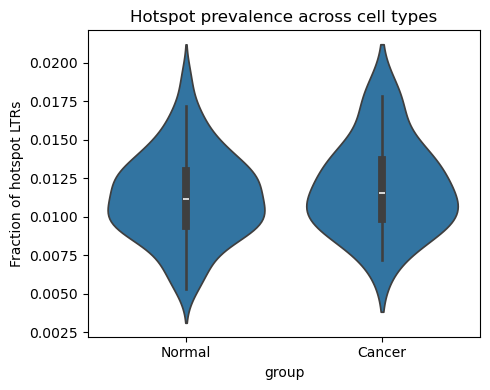

In [7]:
# Quick visualization 

plt.figure(figsize=(5,4))

sns.violinplot(
    data=summary_per_cell,
    x="group",
    y="hotspot_fraction",
    inner="box"
)

plt.ylabel("Fraction of hotspot LTRs")
plt.title("Hotspot prevalence across cell types")

plt.tight_layout()
plt.show()

In [8]:
from scipy.stats import mannwhitneyu

normal = summary_per_cell[summary_per_cell["group"]=="Normal"]["hotspot_fraction"]
cancer = summary_per_cell[summary_per_cell["group"]=="Cancer"]["hotspot_fraction"]

stat, p = mannwhitneyu(normal, cancer)

print("p-value:", p)

p-value: 0.4877743422013622


In [9]:
print(summary_per_cell.groupby("group")["hotspot_fraction"].describe())

        count      mean       std       min       25%       50%       75%  \
group                                                                       
Cancer   16.0  0.011955  0.002900  0.007168  0.009841  0.011563  0.013704   
Normal  111.0  0.011333  0.002844  0.005337  0.009407  0.011162  0.012953   

             max  
group             
Cancer  0.017861  
Normal  0.018968  


In [10]:
print(summary_per_cell.groupby("group")["hotspot_fraction"].mean())

group
Cancer    0.011955
Normal    0.011333
Name: hotspot_fraction, dtype: float64


##### For each LTR locus:
across all cell types:
 - how often is it hotspot?

In [11]:
ltr_variability = (
    df.groupby(["chrom", "start", "end", "name"])
    .agg(
        hotspot_freq=("is_hotspot", "mean"),
        n_celltypes=("is_hotspot", "size")
    )
    .reset_index()
)

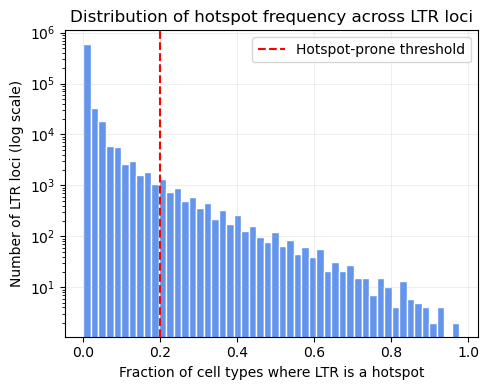

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))

ltr_variability["hotspot_freq"].hist(
    bins=50,
    log=True,
    color="cornflowerblue",
    edgecolor="white"
)

plt.xlabel("Fraction of cell types where LTR is a hotspot")
plt.ylabel("Number of LTR loci (log scale)")
plt.title("Distribution of hotspot frequency across LTR loci")

plt.axvline(0.2, color="red", linestyle="--", label="Hotspot-prone threshold")
plt.grid(alpha=0.2)
plt.legend()

plt.tight_layout()
plt.show()

**So...Hotspot behavior is not random—it is locus-specific and heterogeneous**

In [14]:
ltr_variability["is_hotspot_prone"] = ltr_variability["hotspot_freq"] > 0.2

In [15]:
df = df.merge(ltr_variability[["chrom","start","end","name","hotspot_freq"]],
              on=["chrom","start","end","name"])

df["is_hotspot_prone"] = df["hotspot_freq"] > 0.2

In [16]:
df.groupby("is_hotspot_prone")["entropy"].mean()

is_hotspot_prone
False    0.183103
True     1.296051
Name: entropy, dtype: float64

##### 2. State/category enrichment in hotspot vs non-hotspot